In [96]:
suppressPackageStartupMessages({
library(tidyverse)
library(svglite)
library(ggbreak)
})

options(repr.plot.width = 7, repr.plot.height = 5)

# Helper functions

In [97]:
makeplot = function(df, title, cieling, breaks) {

    # Pivot to longer format. 
    df_long = pivot_longer(df, cols = c(up, down), names_to = "direction", values_to = "count")

    # Convert program and direction to factors. 
    df_long$program = factor(df_long$program, levels = c("DeepRNA-reg", "Ad-hoc", "Diff-Skipper", "Flipper"))
    df_long$direction = factor(df_long$direction, levels = c("up", "down"))

    # Make plot. 
    ggplot(df_long, aes(x = program, y = pmax(count, 1), fill = direction)) +
        geom_bar(stat = "identity", width = 0.7, position = position_dodge(width = 0.7)) +
        geom_blank(data = data.frame(program = "Flipper", direction = "up", count = cieling),
        aes(x = program, y = count)) +
        scale_y_continuous(trans = "sqrt", breaks = breaks) +
        scale_fill_manual(values = c(up = "red", down = "blue"),
                          labels = c(up = "Upregulated binding",down = "Downregulated binding")) +
        labs(title = title, x = "Program", y = "Differential regions found", fill = "Direction") +
        theme_classic() +
        theme(plot.title = element_text(size = 20, face = "bold", hjust = 0.5), text = element_text(size = 16),
              axis.title = element_text(size = 18), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 45, hjust = 1),
              legend.title = element_text(size = 16), legend.text = element_text(size = 14))
}

# NONO

In [98]:
# Load reproducible windows for use when detemining ad-hoc results. 
active_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper_updated/output/reproducible_enriched_windows/10R.reproducible_enriched_windows.tsv.gz",
                          sep = "\t")
inactive_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper_updated/output/reproducible_enriched_windows/10S.reproducible_enriched_windows.tsv.gz",
                            sep = "\t")
DMSO_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/NONO_skipper_updated/output/reproducible_enriched_windows/DMSO.reproducible_enriched_windows.tsv.gz",
                        sep = "\t")

key_cols = c("chr", "start", "end")

## DMSO vs R

### Load data

In [99]:
# NONO results for Flipper.
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R/tables/differential_windows.tsv",
                      sep = "\t")

# NONO results for DeepRNA-reg.
DRR_up = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_R/enriched_cond1_NONO_DMSO_R.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_R/enriched_cond2_NONO_DMSO_R.csv")

# NONO results for Adhoc method.
Adhoc_up = active_windows %>%
  anti_join(DMSO_windows, by = key_cols)

Adhoc_down = DMSO_windows %>%
  anti_join(active_windows, by = key_cols)

# NONO results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10R_DMSO.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/DMSO_10R.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")



### Make plots

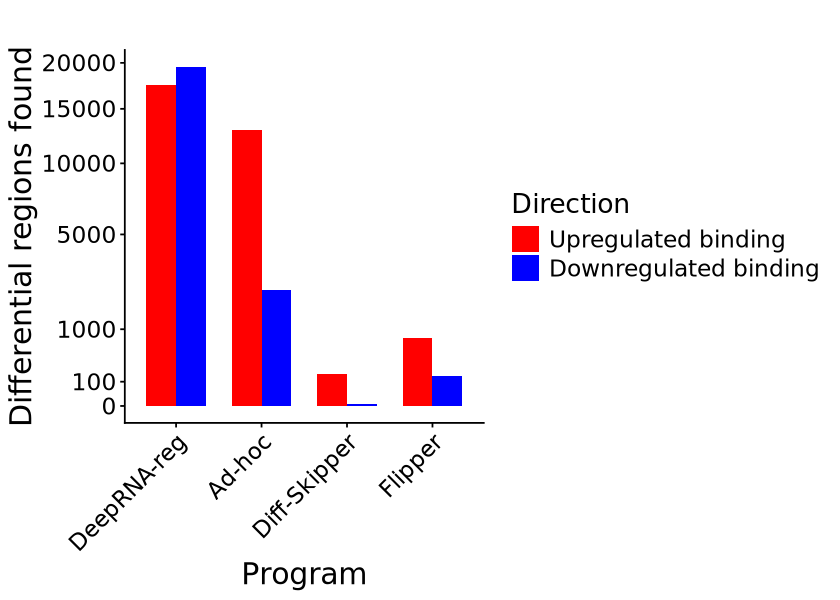

In [100]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 19000, breaks = c(0, 100, 1000, 5000, 10000, 15000, 20000))

ggsave("grouped_barplots/NONO_DMSO_R_barplots.svg", width = 7, height = 5, dpi = 300)


In [101]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,17449,19534,36983
Flipper,775,155,930
Ad-hoc,12953,2273,15226
Diff-Skipper,172,0,172


In [102]:
length(active_windows$chr) + length(DMSO_windows$chr)

[1] 22364

## S vs R

### Load data

In [103]:
# NONO results for Flipper
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_S_R/tables/differential_windows.tsv",
                      sep = "\t")

# NONO results for DeepRNA-reg
DRR_up = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_S_R/enriched_cond1_NONO_S_R.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_S_R/enriched_cond2_NONO_S_R.csv")

# NONO results for Adhoc method.
Adhoc_up = active_windows %>%
  anti_join(inactive_windows, by = key_cols)

Adhoc_down = inactive_windows %>%
  anti_join(active_windows, by = key_cols)

# NONO results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10R_10S.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10S_10R.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")


### Make plots

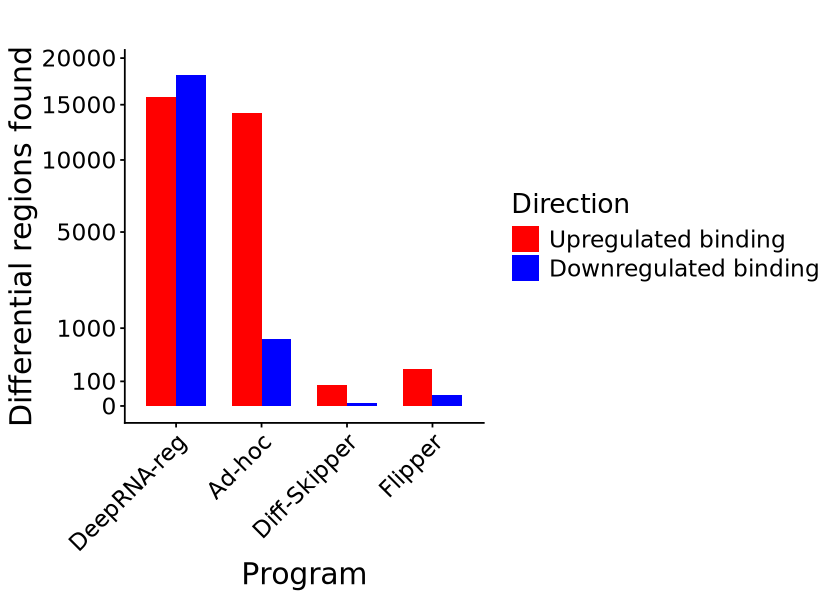

In [104]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 19000, breaks = c(0, 100, 1000, 5000, 10000, 15000, 20000))

ggsave("grouped_barplots/NONO_S_R_barplots.svg", width = 7, height = 5, dpi = 300)


In [105]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,15809,18081,33890
Flipper,230,19,249
Ad-hoc,14175,749,14924
Diff-Skipper,70,0,70


## DMSO vs S

### Load data

In [106]:
# NONO results for Flipper
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_S/tables/differential_windows.tsv",
                      sep = "\t")

# NONO results for Flipper
DRR_up = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_S/enriched_cond1_NONO_DMSO_S.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/NONO_run/results/NONO_DMSO_S/enriched_cond2_NONO_DMSO_S.csv")

# NONO results for Adhoc method.
Adhoc_up = inactive_windows %>%
  anti_join(DMSO_windows, by = key_cols)

Adhoc_down = DMSO_windows %>%
  anti_join(inactive_windows, by = key_cols)

# NONO results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/DMSO_10S.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/NONO_skipper_diff2/output/reproducible_enriched_windows/10S_DMSO.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")


### Make plots

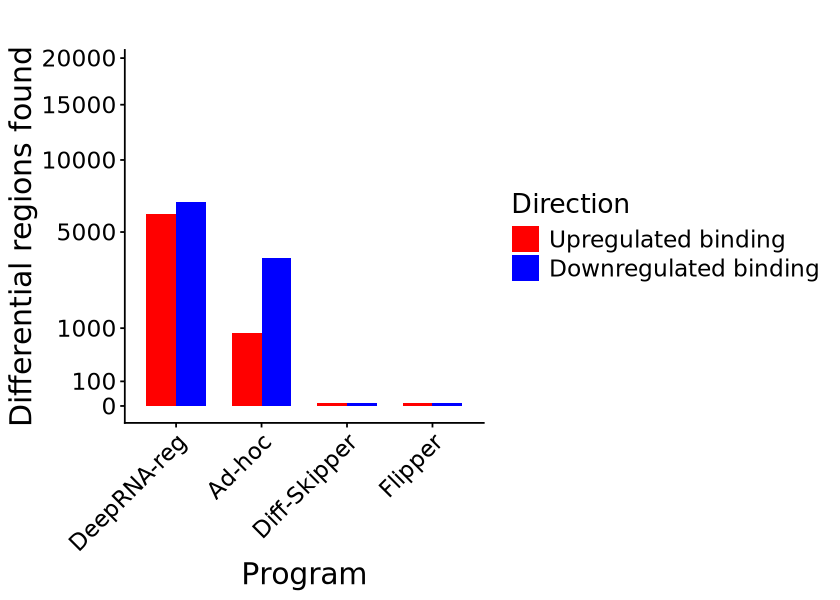

In [107]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 19000, breaks = c(0, 100, 1000, 5000, 10000, 15000, 20000))

ggsave("grouped_barplots/NONO_DMSO_S_barplots.svg", width = 7, height = 5, dpi = 300)


In [108]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,6073,6892,12965
Flipper,0,0,0
Ad-hoc,891,3637,4528
Diff-Skipper,0,1,1


# DDX42

In [109]:
# Load reproducible windows for use when detemining ad-hoc results. 
active_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper_updated/output/reproducible_enriched_windows/MJ-22-51_2A.reproducible_enriched_windows.tsv.gz", 
                          sep="\t")
inactive_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper_updated/output/reproducible_enriched_windows/MJ-22-51_3A.reproducible_enriched_windows.tsv.gz", 
                            sep="\t")
DMSO_windows = read.csv("/tscc/lustre/ddn/scratch/kflanagan/new_skipper_test/testing/results/DDX42_skipper_updated/output/reproducible_enriched_windows/MJ-22-51_1A.reproducible_enriched_windows.tsv.gz",
                        sep="\t")

## DMSO vs active

### Load data

In [110]:
# DDX42 results for Flipper
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active/tables/differential_windows.tsv",
                      sep = "\t")

# DDX42 results for DeepRNA-reg
DRR_up = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_active/enriched_cond1_DDX42_DMSO_active.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_active/enriched_cond2_DDX42_DMSO_active.csv")

# DDX42 results for Adhoc method.
Adhoc_up = active_windows %>%
  anti_join(DMSO_windows, by = key_cols)

Adhoc_down = DMSO_windows %>%
  anti_join(active_windows, by = key_cols)

# DDX42 results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/active_DMSO.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/DMSO_active.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")


### Make plots

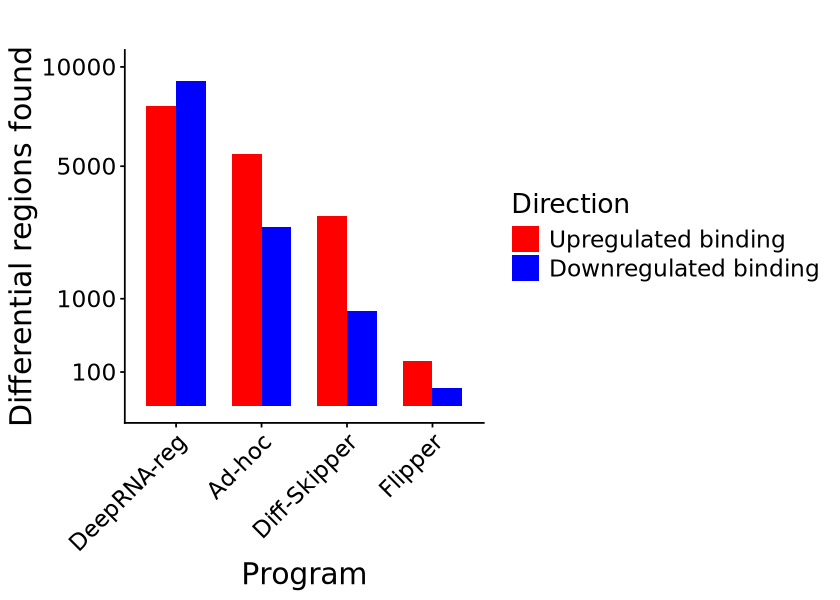

In [111]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 10000, breaks = c(100, 1000, 5000, 10000))

ggsave("grouped_barplots/DDX42_DMSO_active_barplots.svg",
       width = 7, 
       height = 5,
       dpi = 300
      )

In [112]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,7848,9199,17047
Flipper,174,29,203
Ad-hoc,5506,2775,8281
Diff-Skipper,3129,778,3907


## inactive vs active

### Load data

In [113]:
# DDX42 results for Flipper
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_inactive_active/tables/differential_windows.tsv",
                      sep = "\t")

# DDX42 results for DeepRNA-reg
DRR_up = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_inactive_active/enriched_cond1_DDX42_inactive_active.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_inactive_active/enriched_cond2_DDX42_inactive_active.csv")

# DDX42 results for Adhoc method.
Adhoc_up = active_windows %>%
  anti_join(inactive_windows, by = key_cols)

Adhoc_down = inactive_windows %>%
  anti_join(active_windows, by = key_cols)

# DDX42 results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/active_inactive.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/inactive_active.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")


### Make plots

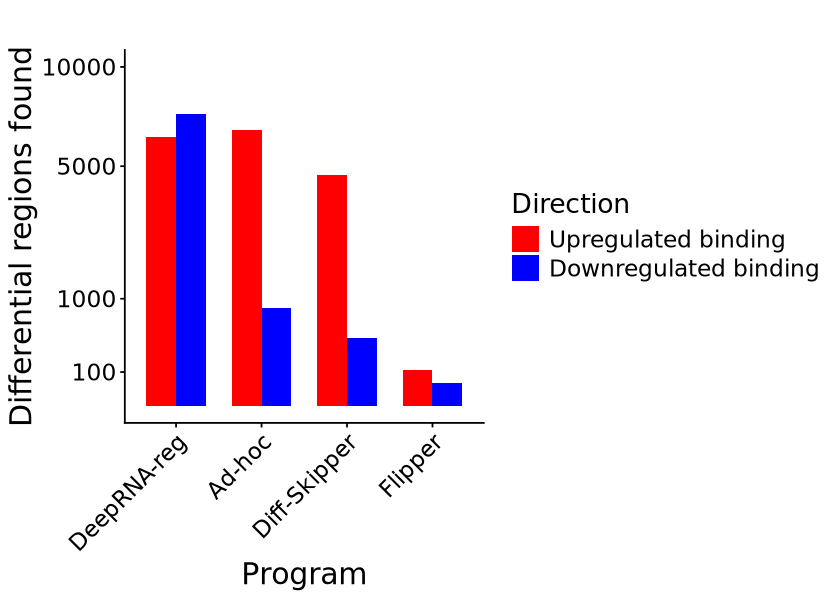

In [114]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 10000, breaks = c(100, 1000, 5000, 10000))

ggsave("grouped_barplots/DDX42_inactive_active_barplots.svg", width = 7, height = 5, dpi = 300)

In [115]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,6312,7403,13715
Flipper,112,45,157
Ad-hoc,6624,839,7463
Diff-Skipper,4623,403,5026


## DMSO vs S

### Load data

In [116]:
# DDX42 results for Flipper
Flipper = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_inactive/tables/differential_windows.tsv",
                      sep = "\t")

# DDX42 results for DeepRNA-reg
DRR_up = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_inactive/enriched_cond1_DDX42_DMSO_inactive.csv")
DRR_down = read.csv("~/scratch/DeepRNA-Reg/DDX42_run/results/DDX42_DMSO_inactive/enriched_cond2_DDX42_DMSO_inactive.csv")

# DDX42 results for Adhoc method.
Adhoc_up = inactive_windows %>%
  anti_join(DMSO_windows, by = key_cols)

Adhoc_down = DMSO_windows %>%
  anti_join(inactive_windows, by = key_cols)

# DDX42 results for differential skipper. 
diff_skip_up = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/inactive_DMSO.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")
diff_skip_down = read.csv("~/scratch/new_skipper_test/testing/results/DDX42_skipper_diff/output/reproducible_enriched_windows/DMSO_inactive.reproducible_enriched_windows.tsv.gz",
                       sep = "\t")


### Make plots

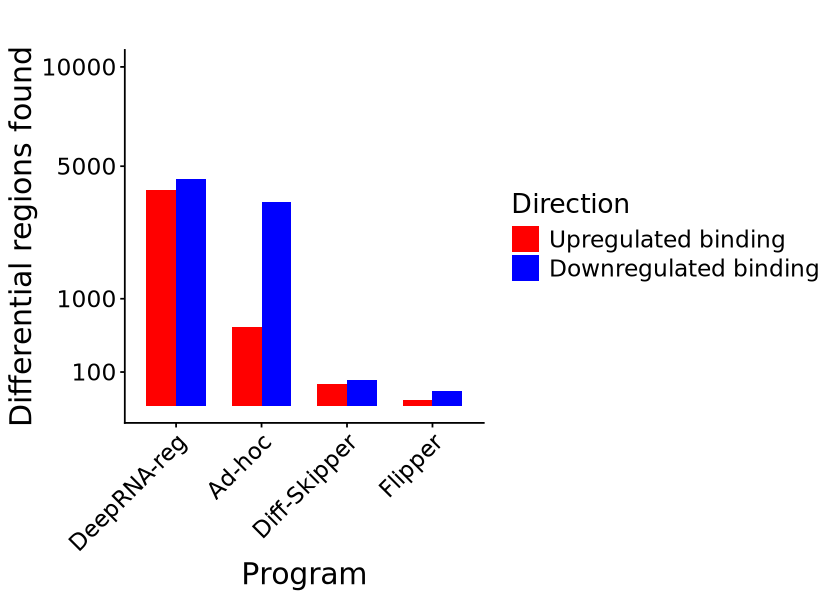

In [117]:
# Create the data.
df = data.frame(program = c("DeepRNA-reg", "Flipper", "Ad-hoc", "Diff-Skipper"),
          up = c(length(DRR_up$chrom),length(subset(Flipper, log2FoldChange > 0)$chr), length(Adhoc_up$chrom),length(diff_skip_up$chr)),
          down = c(length(DRR_down$chrom), length(subset(Flipper, log2FoldChange < 0)$chr), length(Adhoc_down$chrom), length(diff_skip_down$chr)))
df$total = df$up + df$down

makeplot(df, "", cieling = 10000, breaks = c(100, 1000, 5000, 10000))

ggsave("grouped_barplots/DDX42_DMSO_inactive_barplots.svg", width = 7, height = 5, dpi = 300)


In [118]:
df

program,up,down,total
<chr>,<int>,<int>,<int>
DeepRNA-reg,4073,4488,8561
Flipper,3,19,22
Ad-hoc,548,3602,4150
Diff-Skipper,43,59,102
